In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from PIL import Image
from sklearn.decomposition import PCA

In [2]:
df1 = pd.read_csv("s214696_1.csv")
df2 = pd.read_csv("s214696_2.csv")
df3 = pd.read_csv("s224184_1.csv")
df4 = pd.read_csv("s224184_2.csv")
df5 = pd.read_csv("s224223_1.csv")
df6 = pd.read_csv("s224223_2.csv")

df = df1.merge(df2, on="filename", suffixes=("_1", "_2"))
df = df.merge(df3, on="filename")
df = df.merge(df4, on="filename", suffixes=("_3", "_4"))
df = df.merge(df5, on="filename")
df = df.merge(df6, on="filename", suffixes=("_5", "_6"))

print(df.head())

                                filename  rating_1  rating_2  rating_3  \
0  86_0_0_20170111222700442.jpg.chip.jpg         1         1         1   
1  70_1_1_20170110153248874.jpg.chip.jpg         4         5         5   
2  75_0_1_20170111210115928.jpg.chip.jpg         2         2         1   
3  89_0_2_20170112220351776.jpg.chip.jpg         1         1         2   
4  89_1_3_20170110182042731.jpg.chip.jpg         4         4         5   

   rating_4  rating_5  rating_6  
0         1         1         1  
1         5         5         5  
2         1         1         1  
3         1         1         1  
4         5         5         4  


In [3]:
cols = ["rating_1", "rating_2", "rating_3", "rating_4", "rating_5", "rating_6"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
df["avg"] = df[cols].mean(axis=1)

In [4]:
df["age"]    = df["filename"].str.split("_").str[0].astype(int)
df["gender"] = df["filename"].str.split("_").str[1].astype(int)

print(df["gender"].value_counts())
print(df["gender"].value_counts(normalize=True).round(3))

gender
0    135
1    117
Name: count, dtype: int64
gender
0    0.536
1    0.464
Name: proportion, dtype: float64


In [5]:
n = df["gender"].value_counts().min()

df = (df.groupby("gender", group_keys=False)
        .sample(n=n, random_state=0)
        .reset_index(drop=True))

print(df["gender"].value_counts())

gender
0    117
1    117
Name: count, dtype: int64


          rating_1  rating_2  rating_3  rating_4  rating_5  rating_6
rating_1     1.000     0.942     0.935     0.921     0.920     0.914
rating_2     0.942     1.000     0.939     0.923     0.918     0.918
rating_3     0.935     0.939     1.000     0.964     0.938     0.922
rating_4     0.921     0.923     0.964     1.000     0.921     0.919
rating_5     0.920     0.918     0.938     0.921     1.000     0.970
rating_6     0.914     0.918     0.922     0.919     0.970     1.000


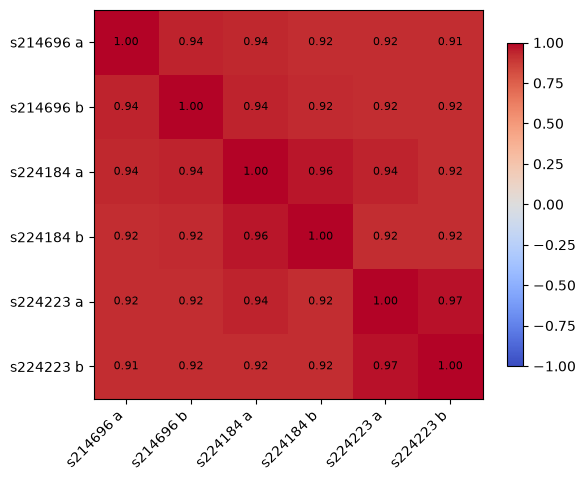

In [6]:
cols = ["rating_1", "rating_2", "rating_3", "rating_4", "rating_5", "rating_6"]
corr = df[cols].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

labels = ["s214696 a", "s214696 b", "s224184 a", "s224184 b", "s224223 a", "s224223 b"]
ax.set_xticks(range(6), labels, rotation=45, ha="right")
ax.set_yticks(range(6), labels)

for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

In [7]:
cols = ["rating_1", "rating_2", "rating_3", "rating_4", "rating_5", "rating_6"]
corr = np.corrcoef(df[cols].values, rowvar=False)
mean_r = corr[np.triu_indices_from(corr, k=1)].mean()
print(round(mean_r, 3))

0.931


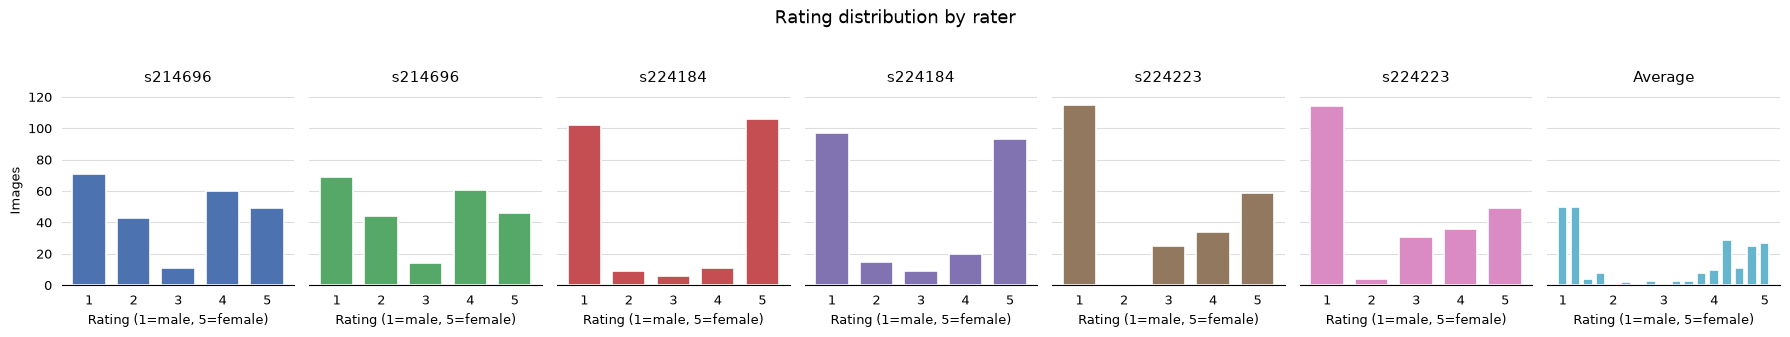

In [8]:
cols   = ["rating_1", "rating_2", "rating_3", "rating_4", "rating_5", "rating_6", "avg"]
titles = ["s214696", "s214696", "s224184", "s224184", "s224223", "s224223", "Average"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3", "#64B5CD"]

int_bins = np.arange(0.5, 6.5, 1)          # one bar per whole rating
avg_bins = np.arange(0.875, 5.26, 0.25)    # quarter steps for the mean

fig, axes = plt.subplots(1, 7, figsize=(18, 3.2), sharey=True)

for ax, col, title, c in zip(axes, cols, titles, colors):
    bins = avg_bins if col == "avg" else int_bins
    ax.hist(df[col].dropna(), bins=bins, rwidth=0.75,
            color=c, edgecolor="white", linewidth=1.2)

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel("Rating (1=male, 5=female)", fontsize=9)

    ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelsize=9)

axes[0].set_ylabel("Images", fontsize=9)
fig.suptitle("Rating distribution by rater", fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig("histogram.png")

In [9]:
folder = Path("70+_clean")
gray_folder = Path("70+_gray")
gray_folder.mkdir(exist_ok=True)

SIZE = (200, 200)

filenames = df["filename"].tolist()

rows = []
for f in filenames:
    img = Image.open(folder / f).convert("L")
    img.save(gray_folder / f)
    rows.append(np.asarray(img, dtype=np.float64).ravel())

X = np.stack(rows)

print(X.shape)

(234, 40000)


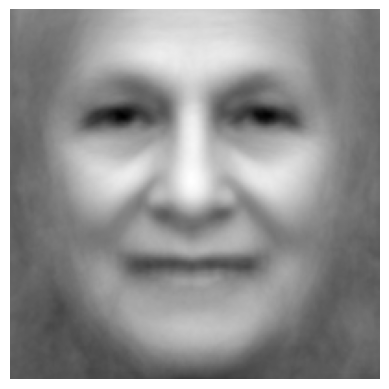

In [10]:
import matplotlib.pyplot as plt

SIZE = (200, 200)
mean_img = X.mean(axis=0)

plt.imshow(mean_img.reshape(SIZE), cmap="gray")
plt.axis("off")
plt.show()

In [11]:
Xc = X - mean_img
pca = PCA()
Z = pca.fit_transform(Xc)
print(Z.shape)

(234, 234)


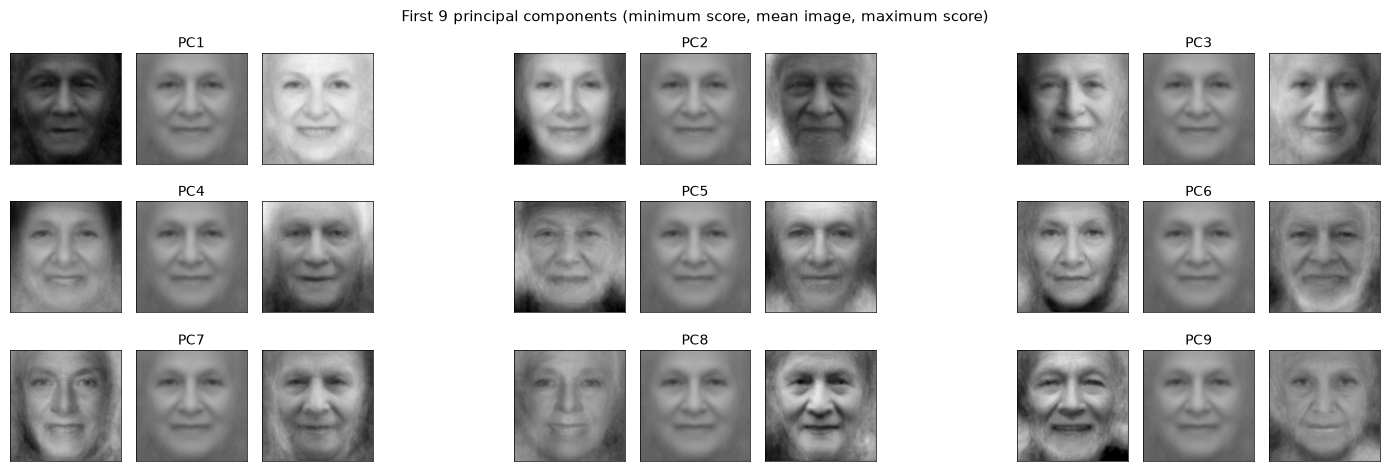

In [12]:
# Visualise the first show_pcs components as images, each shown as the mean face plus the component at its lowest score, the mean face alone, and the mean face plus its highest score
n_show = 9
per_row = 3

show_pcs = list(range(n_show))
n_rows = -(-len(show_pcs) // per_row)

fig, axes = plt.subplots(n_rows, per_row * 4 - 1, figsize=(14, 1.6 * n_rows), squeeze=False)

for ax in axes.ravel():
    ax.axis("off")

for k, nr in enumerate(show_pcs):
    row, col = divmod(k, per_row)
    base = col * 4
    pc = pca.components_[nr]
    s = Z[:, nr]
    imgs = [mean_img + s.min() * pc, mean_img, mean_img + s.max() * pc]

    for j, img in enumerate(imgs):
        ax = axes[row, base + j]
        ax.imshow(img.reshape(SIZE), cmap="gray", vmin=0, vmax=255)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis("on")

    axes[row, base + 1].set_title(f"PC{nr + 1}", fontsize=10, pad=4)

fig.suptitle(f"First {len(show_pcs)} principal components (minimum score, mean image, maximum score)", fontsize=11)
plt.tight_layout()
plt.subplots_adjust(hspace=0.25)
plt.savefig(f"pcs_first{n_show}.png", dpi=150)
plt.show()

In [29]:
# Order all PCs by how strongly they correlate with our ratings, strongest first.
# This is just a check - forward selection does the real picking later.
# We use it to see how far down the list the useful components go, so we know how many to keep as candidates (elbow).
# We also correlate with the dataset's own gender label, to see whether the components that predict our ratings are the same ones that predict the label.
variance = pca.explained_variance_ratio_

r = np.array([np.corrcoef(Z[:, k], df["avg"])[0, 1] for k in range(Z.shape[1])])
r_label = np.array([np.corrcoef(Z[:, k], df["gender"])[0, 1] for k in range(Z.shape[1])])

order = np.argsort(-np.abs(r))
for k in order[:20]:
    print(f"PC{k+1:>3}: variance {variance[k]:6.2%}   r ratings {r[k]:+.3f}   r label {r_label[k]:+.3f}")

PC  2: variance 12.79%   r ratings -0.290   r label -0.273
PC 17: variance  0.74%   r ratings -0.233   r label -0.220
PC 29: variance  0.42%   r ratings -0.223   r label -0.238
PC 23: variance  0.52%   r ratings +0.221   r label +0.175
PC  6: variance  2.46%   r ratings -0.214   r label -0.226
PC  1: variance 26.43%   r ratings +0.199   r label +0.147
PC 25: variance  0.49%   r ratings -0.173   r label -0.176
PC  8: variance  1.92%   r ratings -0.169   r label -0.148
PC 33: variance  0.37%   r ratings +0.150   r label +0.187
PC 16: variance  0.83%   r ratings -0.148   r label -0.158
PC 13: variance  1.00%   r ratings +0.143   r label +0.133
PC115: variance  0.07%   r ratings +0.134   r label +0.149
PC 90: variance  0.10%   r ratings +0.134   r label +0.129
PC 26: variance  0.47%   r ratings +0.131   r label +0.114
PC 15: variance  0.84%   r ratings +0.128   r label +0.127
PC107: variance  0.08%   r ratings -0.128   r label -0.118
PC 46: variance  0.24%   r ratings -0.126   r label -0.1

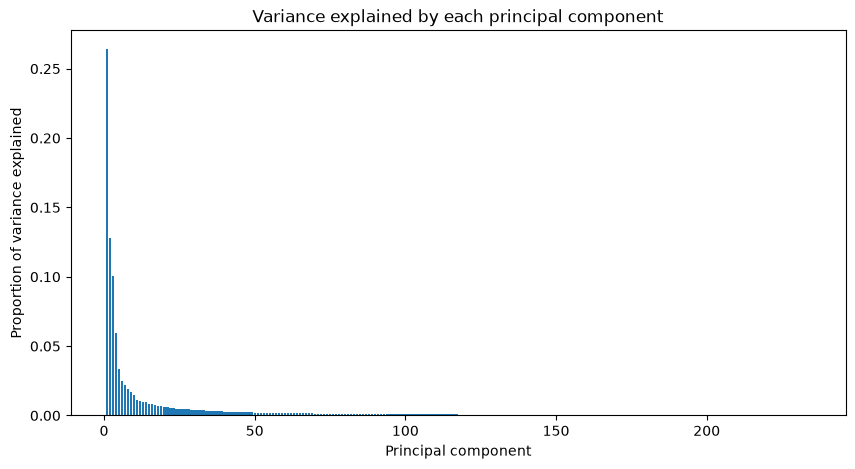

In [14]:
variance = pca.explained_variance_ratio_

plt.figure(figsize=(10, 5))
plt.bar(np.arange(1, len(variance) + 1), variance)

plt.xlabel("Principal component")
plt.ylabel("Proportion of variance explained")
plt.title("Variance explained by each principal component")
plt.savefig("scree_all.png", dpi=150)
plt.show()

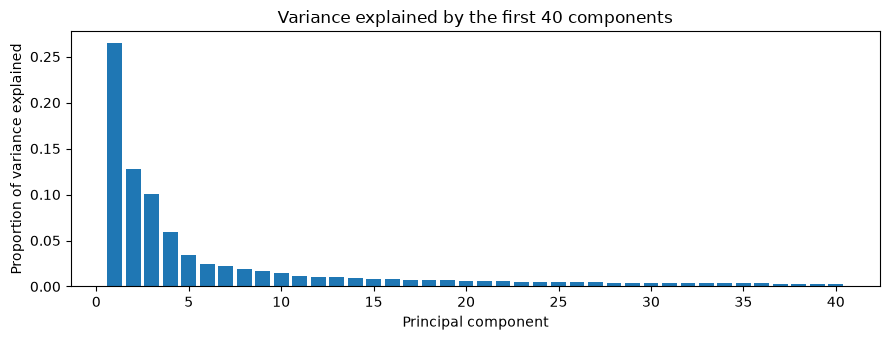

In [15]:
# Zoom in on the first 40 components to locate the elbow.
K_SHOW = 40

plt.figure(figsize=(9, 3.5))
plt.bar(np.arange(1, K_SHOW + 1), variance[:K_SHOW])
plt.xlabel("Principal component")
plt.ylabel("Proportion of variance explained")
plt.title("Variance explained by the first 40 components")
plt.tight_layout()
plt.savefig("scree_zoom.png", dpi=150)
plt.show()

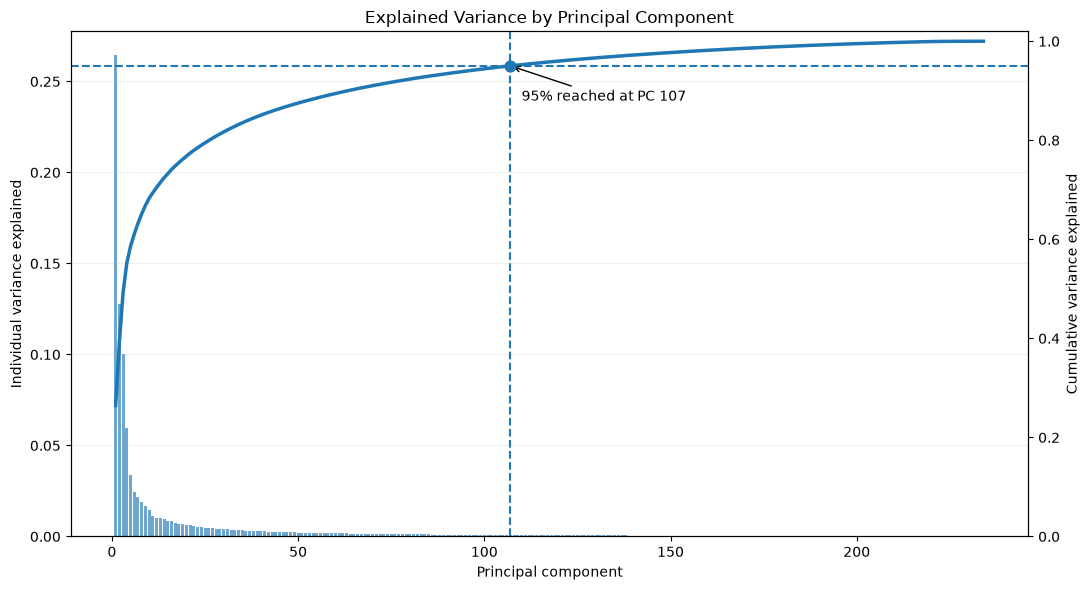

Number of PCs needed to explain at least 95% of the variance: 107


In [16]:
variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance)

pcs = np.arange(1, len(variance) + 1)

# First PC where cumulative explained variance reaches 95%
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

fig, ax1 = plt.subplots(figsize=(11, 6))

# Individual explained variance
ax1.bar(
    pcs,
    variance,
    alpha=0.65,
    label="Individual variance explained"
)

ax1.set_xlabel("Principal component")
ax1.set_ylabel("Individual variance explained")
ax1.grid(axis="y", alpha=0.2)

# Cumulative explained variance
ax2 = ax1.twinx()

ax2.plot(
    pcs,
    cumulative_variance,
    linewidth=2.5,
    label="Cumulative variance explained"
)

ax2.set_ylabel("Cumulative variance explained")
ax2.set_ylim(0, 1.02)

# 95% horizontal threshold
ax2.axhline(
    0.95,
    linestyle="--",
    linewidth=1.5
)

# Vertical line showing number of PCs needed
ax2.axvline(
    n_95,
    linestyle="--",
    linewidth=1.5
)

# Highlight the 95% point
ax2.scatter(
    n_95,
    cumulative_variance[n_95 - 1],
    s=60,
    zorder=5
)

ax2.annotate(
    f"95% reached at PC {n_95}",
    xy=(n_95, cumulative_variance[n_95 - 1]),
    xytext=(n_95 + 3, 0.88),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.title("Explained Variance by Principal Component")

fig.tight_layout()
plt.show()

print(f"Number of PCs needed to explain at least 95% of the variance: {n_95}")

In [17]:
# Cut at the elbow in the scree plot.
# We keep 40 components as candidates for the forward selection—enough that we do not throw away components that matter for the ratings, but few enough to avoid overfitting with only 234 images.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

K = 40
Z_sel = Z[:, :K]
y = df["avg"].values

print(f"Keeping {K} components, explaining {variance[:K].sum():.1%} of the variance")
print("Z_sel:", Z_sel.shape)

Keeping 40 components, explaining 85.1% of the variance
Z_sel: (234, 40)


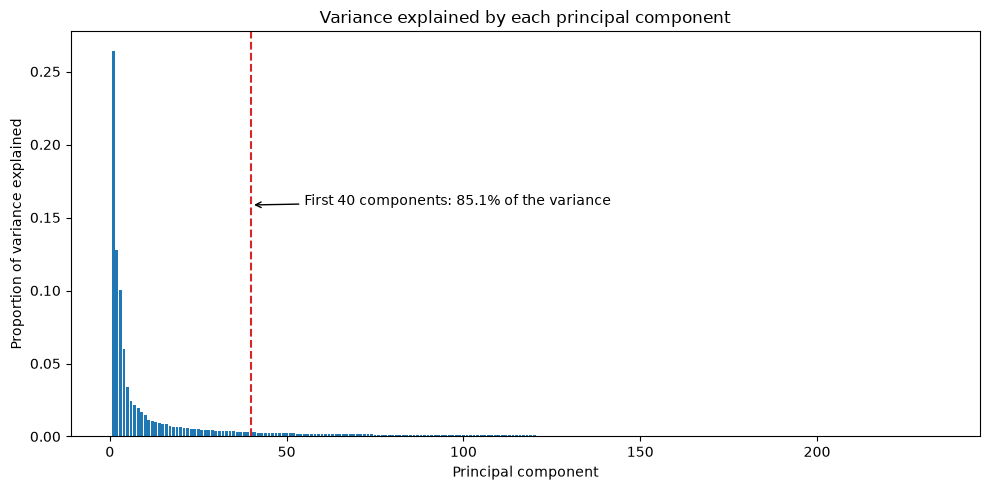

In [28]:
variance = pca.explained_variance_ratio_
pcs = np.arange(1, len(variance) + 1)

plt.figure(figsize=(10, 5))
plt.bar(pcs, variance)
plt.axvline(K, linestyle="--", linewidth=1.5, color="tab:red")
plt.annotate(f"First {K} components: {variance[:K].sum():.1%} of the variance",
             xy=(K, variance.max() * 0.6), xytext=(K + 15, variance.max() * 0.6),
             arrowprops=dict(arrowstyle="->"), fontsize=10)

plt.xlabel("Principal component")
plt.ylabel("Proportion of variance explained")
plt.title("Variance explained by each principal component")
plt.tight_layout()
plt.savefig(f"scree_all_{K}_components.png", dpi=150)
plt.show()

### Step 4: Forward Selection

Lowest CV error at 25 components
Order picked: ['PC2', 'PC29', 'PC23', 'PC6', 'PC17', 'PC1', 'PC33', 'PC16', 'PC8', 'PC25', 'PC15', 'PC28', 'PC9', 'PC13', 'PC31', 'PC4', 'PC14', 'PC11', 'PC3', 'PC26', 'PC37', 'PC12', 'PC22', 'PC30', 'PC40', 'PC38', 'PC18', 'PC32', 'PC24', 'PC7', 'PC20', 'PC19', 'PC39', 'PC21', 'PC10', 'PC34', 'PC5', 'PC27', 'PC35', 'PC36']


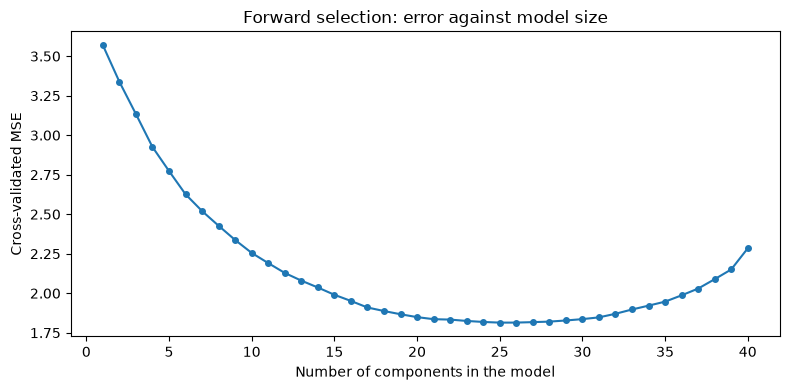

In [18]:
# Run forward selection: start with no components, then add the one that helps most, and repeat.
# Each candidate is judged with cross-validation, not on the training data, because more parameters always fit the training data better.
# We run all K=40 steps and plot the error so we can see where it stops improving.
selected_order, remaining, cv_errors = [], list(range(K)), []

for _ in range(K):
    best = min(remaining, key=lambda c: -cross_val_score(
        LinearRegression(), Z_sel[:, selected_order + [c]], y,
        cv=5, scoring="neg_mean_squared_error").mean())
    selected_order.append(best)
    remaining.remove(best)
    cv_errors.append(-cross_val_score(
        LinearRegression(), Z_sel[:, selected_order], y,
        cv=5, scoring="neg_mean_squared_error").mean())

cv_errors = np.array(cv_errors)
print(f"Lowest CV error at {cv_errors.argmin() + 1} components")
print("Order picked:", [f"PC{i+1}" for i in selected_order])

plt.figure(figsize=(8, 4))
plt.plot(range(1, K + 1), cv_errors, marker="o", markersize=4)
plt.xlabel("Number of components in the model")
plt.ylabel("Cross-validated MSE")
plt.title("Forward selection: error against model size")
plt.tight_layout()
plt.savefig("forward_selection.png", dpi=150)
plt.show()

In [19]:
# Compare a few model sizes before we settle on one
for n in [15, 20, 25]:
    print(f"{n:>3} components: CV MSE = {cv_errors[n-1]:.3f}")

 15 components: CV MSE = 1.990
 20 components: CV MSE = 1.849
 25 components: CV MSE = 1.814


In [20]:
# The curve levels off from around 20 components. The formal minimum is at 25, but the gain from 20 to 25 is only 1.849-1.814=0.035 in MSE, so we keep the smaller model.
n_final = 20
final_pcs = selected_order[:n_final]

print("Final components:", [f"PC{i+1}" for i in final_pcs])
print(f"CV error at {n_final}: {cv_errors[n_final-1]:.3f}  (best was {cv_errors.min():.3f})")

Final components: ['PC2', 'PC29', 'PC23', 'PC6', 'PC17', 'PC1', 'PC33', 'PC16', 'PC8', 'PC25', 'PC15', 'PC28', 'PC9', 'PC13', 'PC31', 'PC4', 'PC14', 'PC11', 'PC3', 'PC26']
CV error at 20: 1.849  (best was 1.814)


In [21]:
# Fit the final model on all 234 images using only the selected components.
# Cross-validation was used to choose the components; now we use everything to get the best estimate of the weights.
model = LinearRegression().fit(Z_sel[:, final_pcs], y)

w_pc = model.coef_ # one weight per selected component
delta = model.intercept_ # the rating of the average face

print(f"delta = {delta:.3f}   (mean rating = {y.mean():.3f})")
print(f"R2 on all data: {model.score(Z_sel[:, final_pcs], y):.3f}")

delta = 2.839   (mean rating = 2.839)
R2 on all data: 0.548


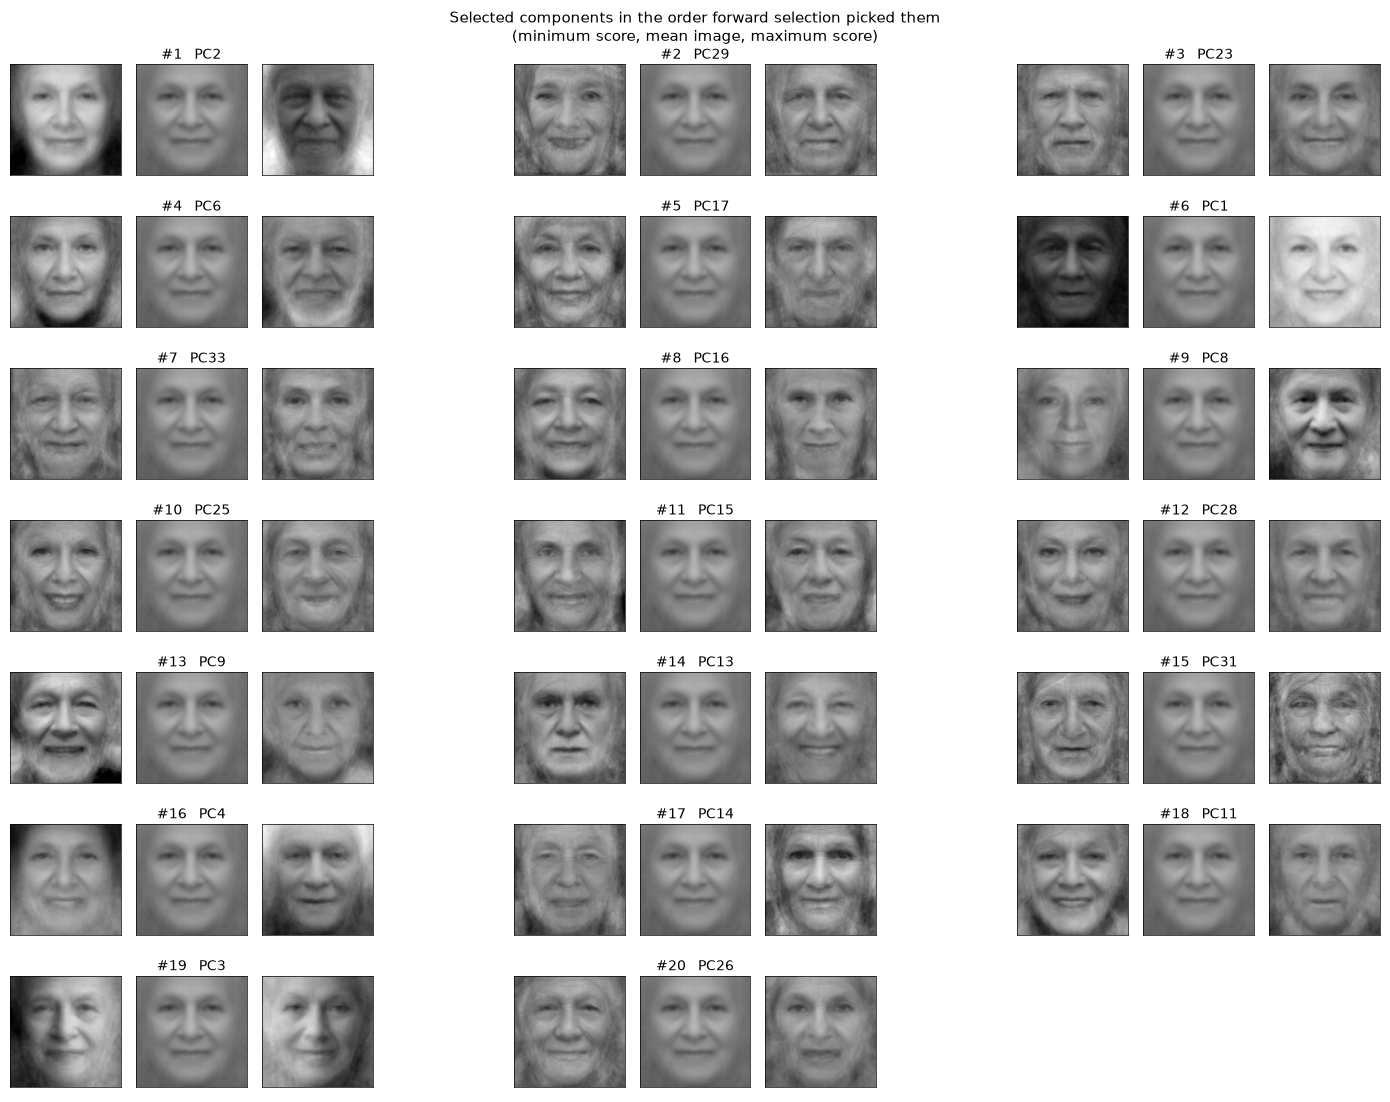

In [37]:
# Look at the components the selection picked, using the same three-image view as in step 3.
# We want to see whether they actually show something related to perceived sex, or just lighting and other things.
per_row = 3
n_rows = -(-len(final_pcs) // per_row)

fig, axes = plt.subplots(n_rows, per_row * 4 - 1, figsize=(14, 1.6 * n_rows), squeeze=False)

for ax in axes.ravel():
    ax.axis("off")

for k, nr in enumerate(final_pcs):
    row, col = divmod(k, per_row)
    base = col * 4
    pc = pca.components_[nr]
    s = Z[:, nr]
    imgs = [mean_img + s.min() * pc, mean_img, mean_img + s.max() * pc]

    for j, img in enumerate(imgs):
        ax = axes[row, base + j]
        ax.imshow(img.reshape(SIZE), cmap="gray", vmin=0, vmax=255)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis("on")

    axes[row, base + 1].set_title(f"#{k + 1}   PC{nr + 1}", fontsize=10, pad=4)

fig.suptitle("Selected components in the order forward selection picked them\n(minimum score, mean image, maximum score)", fontsize=11)
plt.tight_layout()
plt.subplots_adjust(hspace=0.25)
plt.savefig(f"pcs_selected_{n_final}.png", dpi=150)
plt.show()

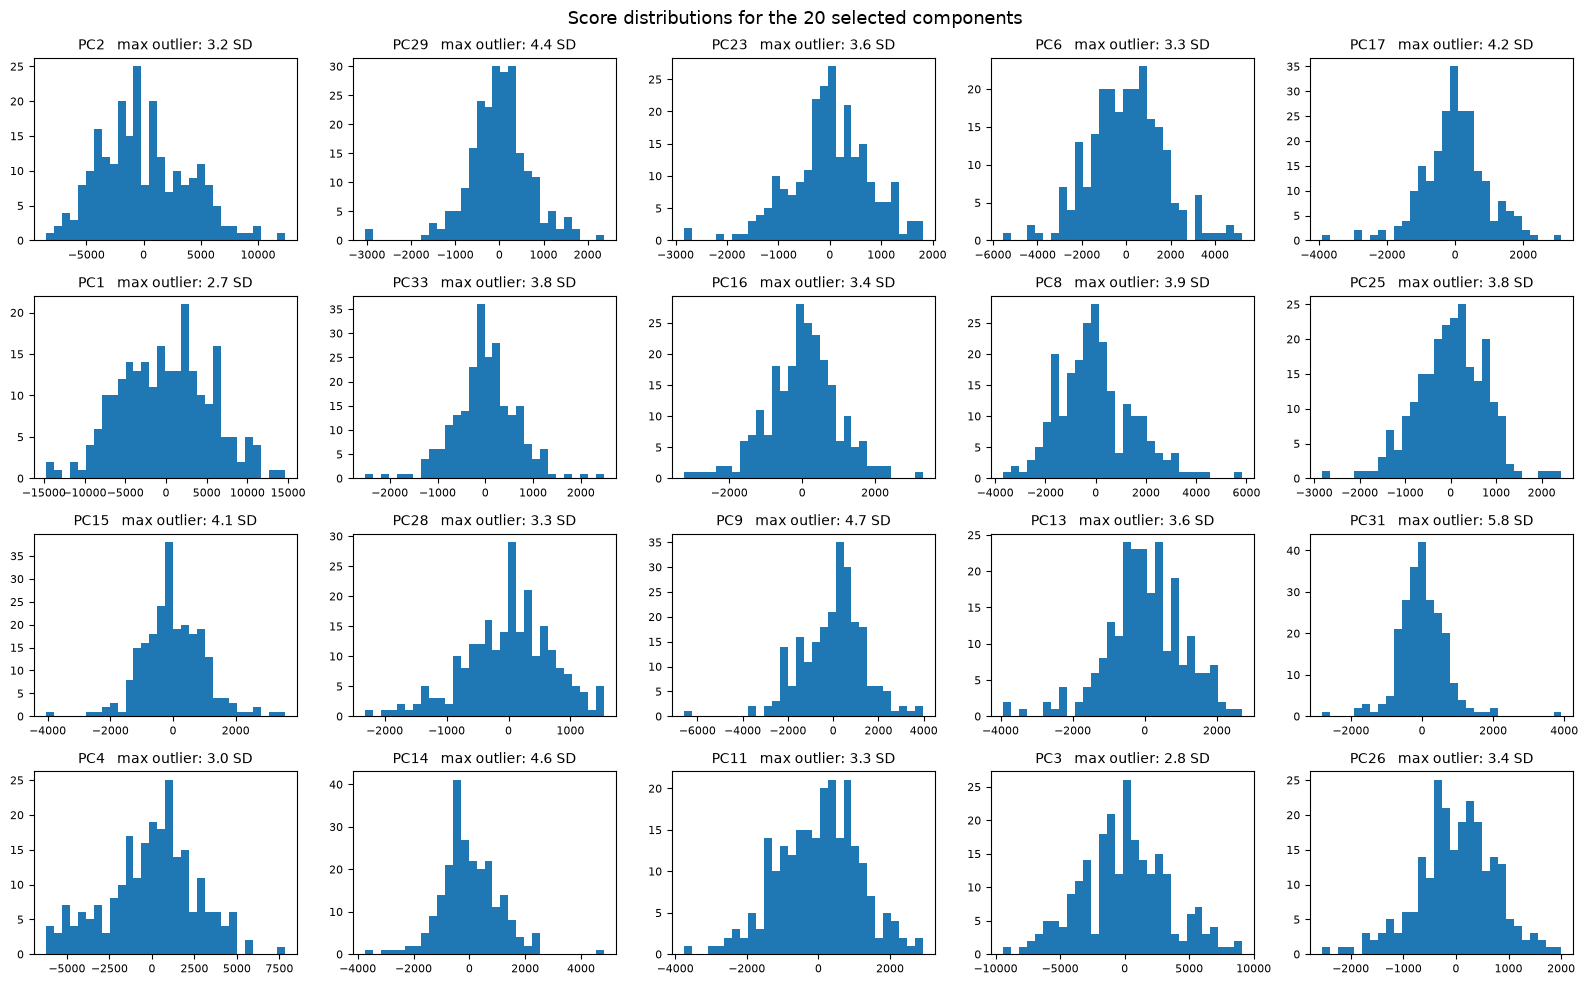

In [31]:
# Plot the score distribution for every component in the final model.
# A real dimension gives a smooth spread; an outlier component gives one point sitting far out on its own, with a gap between it and the rest.
fig, axes = plt.subplots(4, 5, figsize=(16, 10))

for ax, nr in zip(axes.ravel(), final_pcs):
    s = Z[:, nr]
    ax.hist(s, bins=30)
    ax.set_title(f"PC{nr+1}   max outlier: {np.abs(s).max() / s.std():.1f} SD", fontsize=10)
    ax.tick_params(labelsize=8)

fig.suptitle("Score distributions for the 20 selected components", fontsize=13)
plt.tight_layout()
plt.savefig(f"score_distributions_{n_final}.png", dpi=150)
plt.show()

In [24]:
# Find the images driving the extreme scores across all 20 components.
# If the same file keeps turning up, we probably have one bad image rather than 20 odd components.
from collections import Counter

worst = Counter()
for nr in final_pcs:
    s = Z[:, nr]
    if np.abs(s).max() / s.std() > 4:
        worst[df["filename"].iloc[np.abs(s).argmax()]] += 1

for fn, count in worst.most_common():
    print(f"{count}x  {fn}")

1x  85_1_3_20170110183506044.jpg.chip.jpg
1x  90_0_2_20170111210301275.jpg.chip.jpg
1x  77_0_1_20170117173757948.jpg.chip.jpg
1x  75_0_0_20170117173011522.jpg.chip.jpg
1x  75_0_0_20170111205739880.jpg.chip.jpg
1x  96_1_2_20170110182526540.jpg.chip.jpg


In [39]:
# Check how often each image sits at either end of the selected components. One image turning up repeatedly would mean it is shaping several components.
ends = Counter()
where = {}
for k, nr in enumerate(final_pcs):
    s = Z[:, nr]
    for idx in [s.argmin(), s.argmax()]:
        fn = df["filename"].iloc[idx]
        ends[fn] += 1
        where.setdefault(fn, []).append(f"#{k+1} (PC{nr+1})")

for fn, count in ends.most_common(3):
    print(f"{count}x  {fn}")
    print("    ", ", ".join(where[fn]))

5x  75_0_0_20170111205739880.jpg.chip.jpg
     #5 (PC17), #9 (PC8), #14 (PC13), #15 (PC31), #18 (PC11)
3x  90_0_2_20170111210301275.jpg.chip.jpg
     #5 (PC17), #15 (PC31), #18 (PC11)
3x  77_0_1_20170117173757948.jpg.chip.jpg
     #7 (PC33), #11 (PC15), #17 (PC14)


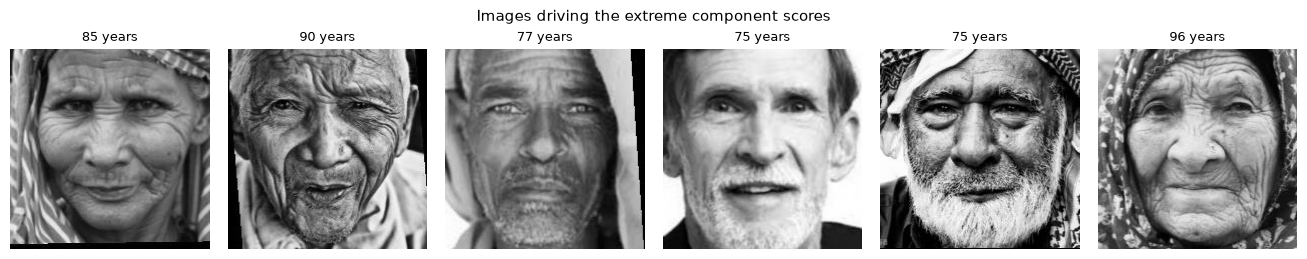

In [25]:
# Look at the images that came up. Something visibly odd here would explain the isolated scores, and would mean the image should have been dropped in step 1.
files = list(worst)

fig, axes = plt.subplots(1, len(files), figsize=(2.2 * len(files), 2.6))

for ax, fn in zip(np.atleast_1d(axes), files):
    i = df.index[df["filename"] == fn][0]
    ax.imshow(X[i].reshape(SIZE), cmap="gray", vmin=0, vmax=255)
    ax.set_title(fn.split("_")[0] + " years", fontsize=9)
    ax.axis("off")

fig.suptitle("Images driving the extreme component scores", fontsize=11)
plt.tight_layout()
plt.show()

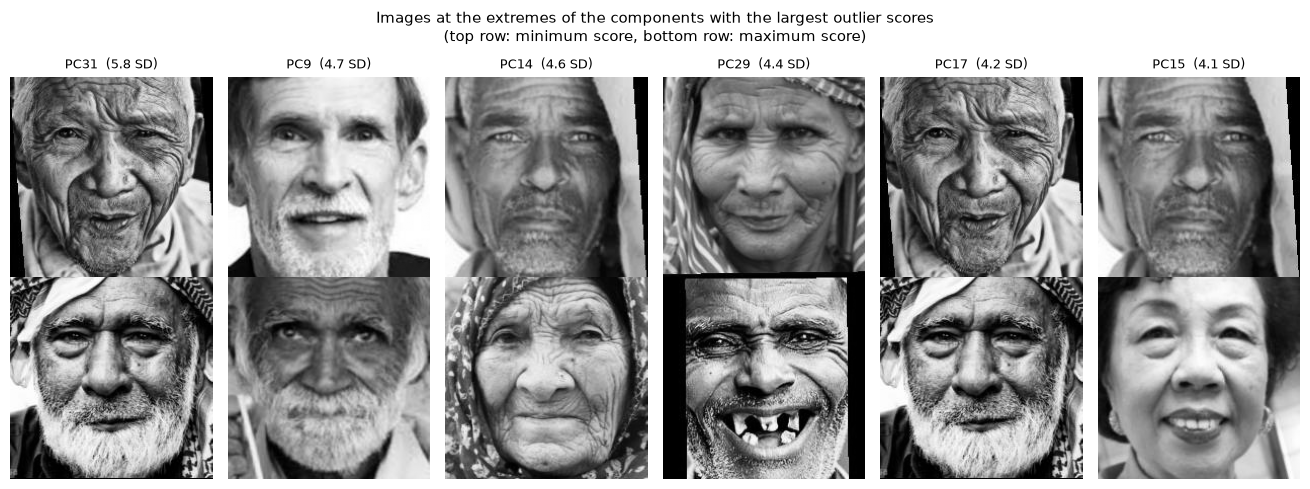

In [ ]:
# For each component with an extreme score, show the image at the minimum and the image at the maximum
extremes = []
for nr in final_pcs:
    s = Z[:, nr]
    sd = np.abs(s).max() / s.std()
    if sd > 4:
        extremes.append((sd, nr))

extremes.sort(reverse=True)

fig, axes = plt.subplots(2, len(extremes), figsize=(2.2 * len(extremes), 5), squeeze=False)

for col, (sd, nr) in enumerate(extremes):
    s = Z[:, nr]
    for row, idx in enumerate([s.argmin(), s.argmax()]):
        ax = axes[row, col]
        ax.imshow(X[idx].reshape(SIZE), cmap="gray", vmin=0, vmax=255)
        ax.axis("off")
        if row == 0:
            ax.set_title(f"PC{nr+1}  ({sd:.1f} SD)", fontsize=9)

axes[0, 0].set_ylabel("Minimum")
axes[1, 0].set_ylabel("Maximum")

fig.suptitle("Images at the extremes of the components with the largest outlier scores\n(top row: minimum score, bottom row: maximum score)", fontsize=11)
plt.tight_layout()
plt.savefig("extreme_images.png", dpi=150)plt.show()

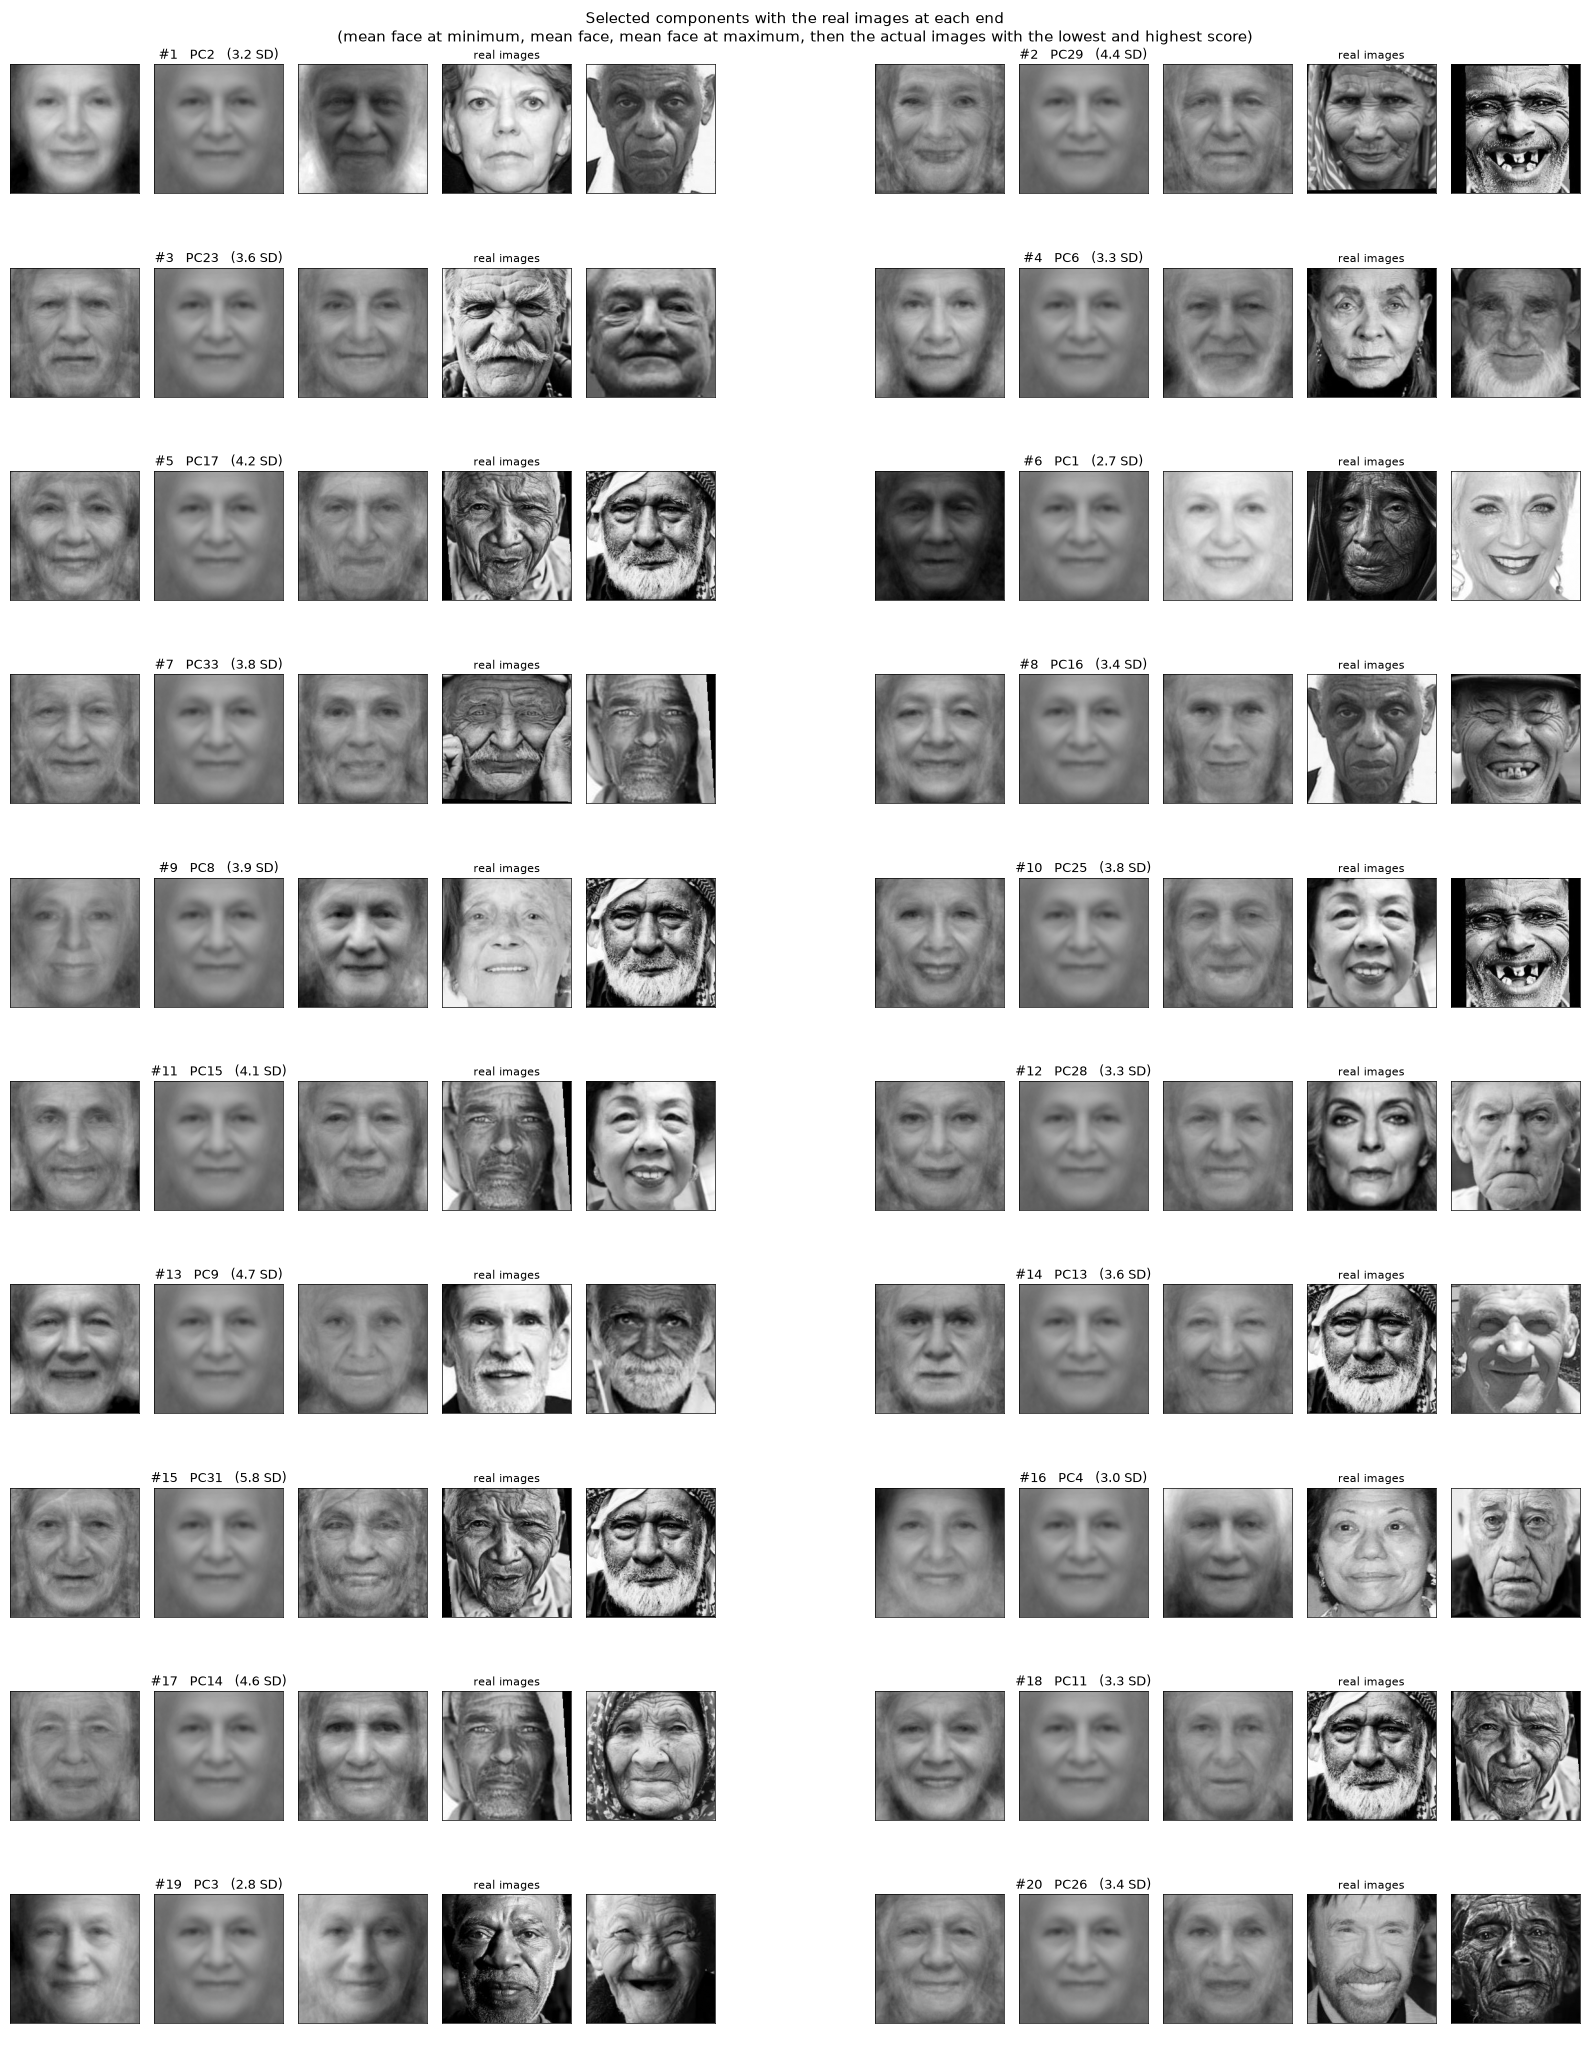

In [36]:
per_row = 2
n_rows = -(-len(final_pcs) // per_row)

fig, axes = plt.subplots(n_rows, per_row * 6 - 1, figsize=(16, 2.1 * n_rows), squeeze=False)

for ax in axes.ravel():
    ax.axis("off")

for k, nr in enumerate(final_pcs):
    row, col = divmod(k, per_row)
    base = col * 6
    pc = pca.components_[nr]
    s = Z[:, nr]

    panels = [
        mean_img + s.min() * pc,
        mean_img,
        mean_img + s.max() * pc,
        X[s.argmin()],
        X[s.argmax()],
    ]

    for j, img in enumerate(panels):
        ax = axes[row, base + j]
        ax.imshow(img.reshape(SIZE), cmap="gray", vmin=0, vmax=255)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis("on")

    sd = np.abs(s).max() / s.std()
    axes[row, base + 1].set_title(f"#{k + 1}   PC{nr + 1}   ({sd:.1f} SD)", fontsize=9, pad=4)
    axes[row, base + 3].set_title("real images", fontsize=8, pad=4)

fig.suptitle("Selected components with the real images at each end\n(mean face at minimum, mean face, mean face at maximum, then the actual images with the lowest and highest score)", fontsize=11)
plt.tight_layout()
plt.savefig(f"pcs_selected_{n_final}_with_extremes.png", dpi=150)
plt.show()

### Step 5 synthetic face generation

In [26]:
#generate synthetic images based on rating
